### 02: EDA по таблице Cell_Avail (доступности)


In [ ]:
df = df_cell_avail.copy()

In [ ]:
# Преобразование дат
df['RECDATE'] = pd.to_datetime(df['RECDATE'])

# Добавление временных признаков
df['Year'] = df['RECDATE'].dt.year
df['Month'] = df['RECDATE'].dt.month
df['DayOfWeek'] = df['RECDATE'].dt.dayofweek  # 0=Monday, 6=Sunday
df['DayName'] = df['RECDATE'].dt.day_name()
df['MonthName'] = df['RECDATE'].dt.month_name()

# Колонки с доступностью
avail_cols = ['Cell Avail 2G (%)', 'Cell Avail 3G (%)', 'Cell Avail 4G (%)', 'Cell Avail Base Tech (%)']
for col in avail_cols:
  df[col] = 100 - df[col]
print(f"Всего записей: {len(df)}")
print(f"Период: {df['RECDATE'].min()} - {df['RECDATE'].max()}")
print(f"Уникальных станций: {df['Master Site'].nunique()}")

Всего записей: 738728
Период: 2023-07-01 00:00:00 - 2025-12-31 00:00:00
Уникальных станций: 919


- Средняя доступность по дням
- Средняя доступность по технологиям
- Средняя доступность по годам
- Распределение по годам  
Сохранено в `1_time_series.png`
####

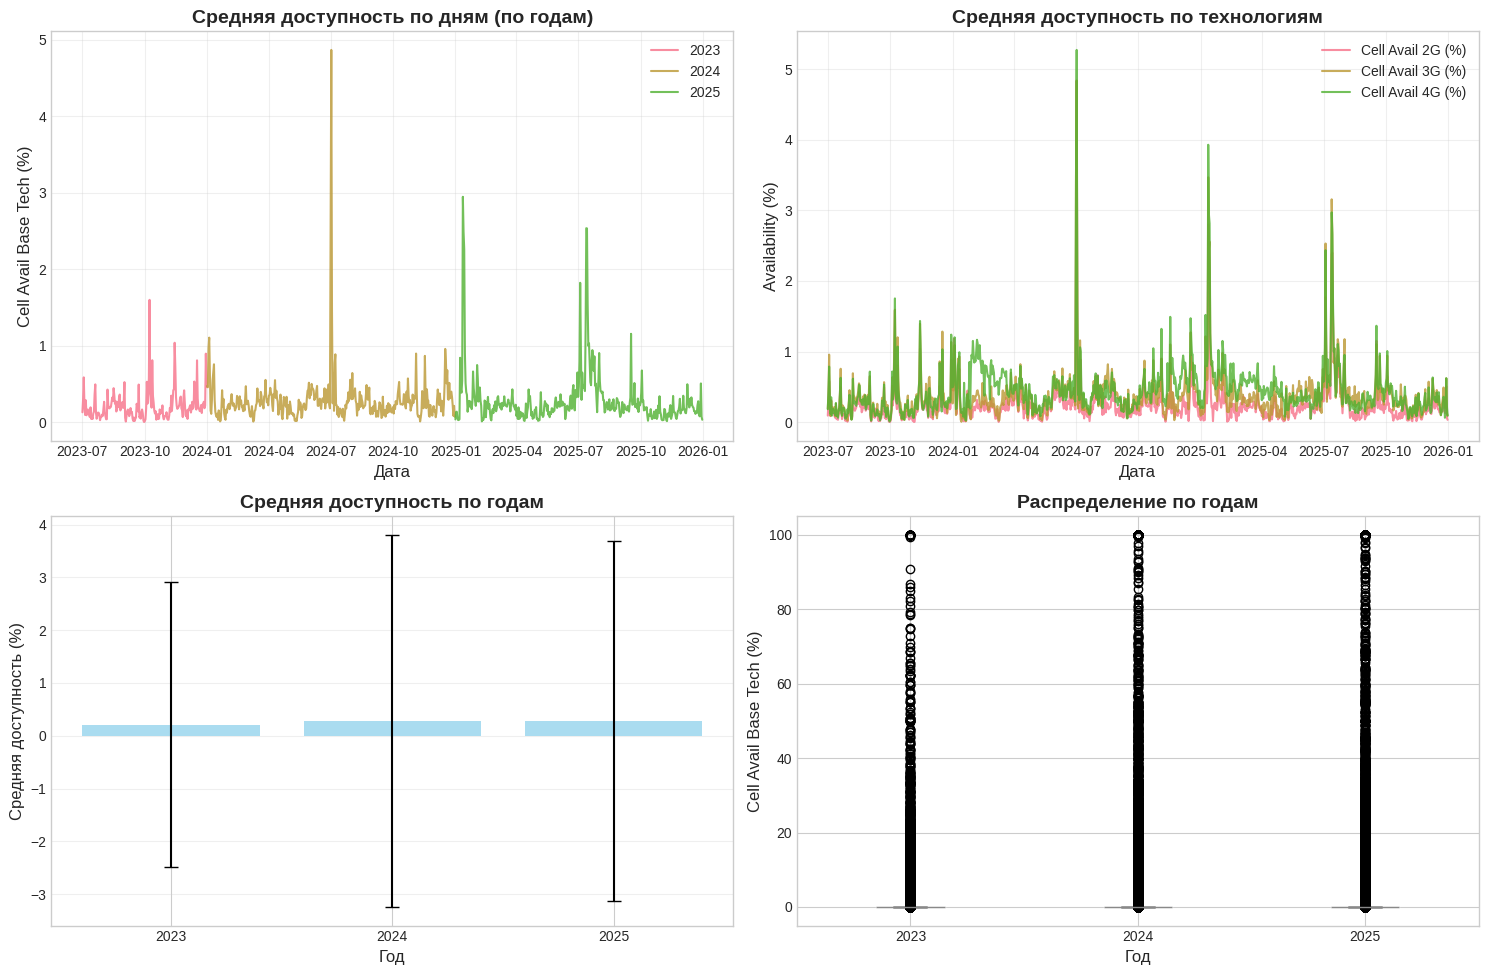

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Среднее по всем станциям по времени
daily_mean = df.groupby('RECDATE')['Cell Avail Base Tech (%)'].mean().reset_index()

for year in sorted(df['Year'].unique()):
    year_data = daily_mean[daily_mean['RECDATE'].dt.year == year]
    axes[0, 0].plot(year_data['RECDATE'], year_data['Cell Avail Base Tech (%)'],
                    label=str(year), linewidth=1.5, alpha=0.8)

axes[0, 0].set_xlabel('Дата', fontsize=12)
axes[0, 0].set_ylabel('Cell Avail Base Tech (%)', fontsize=12)
axes[0, 0].set_title('Средняя доступность по дням (по годам)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Отдельно по каждой технологии
for col in avail_cols[:3]:  # 2G, 3G, 4G
    col_mean = df.groupby('RECDATE')[col].mean()
    axes[0, 1].plot(col_mean.index, col_mean.values, label=col, linewidth=1.5, alpha=0.8)

axes[0, 1].set_xlabel('Дата', fontsize=12)
axes[0, 1].set_ylabel('Availability (%)', fontsize=12)
axes[0, 1].set_title('Средняя доступность по технологиям', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Распределение по годам
yearly_stats = df.groupby('Year')['Cell Avail Base Tech (%)'].agg(['mean', 'median', 'std']).reset_index()
axes[1, 0].bar(yearly_stats['Year'].astype(str), yearly_stats['mean'],
               yerr=yearly_stats['std'], capsize=5, alpha=0.7, color='skyblue')
axes[1, 0].set_xlabel('Год', fontsize=12)
axes[1, 0].set_ylabel('Средняя доступность (%)', fontsize=12)
axes[1, 0].set_title('Средняя доступность по годам', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Boxplot по годам
df.boxplot(column='Cell Avail Base Tech (%)', by='Year', ax=axes[1, 1])
axes[1, 1].set_xlabel('Год', fontsize=12)
axes[1, 1].set_ylabel('Cell Avail Base Tech (%)', fontsize=12)
axes[1, 1].set_title('Распределение по годам', fontsize=14, fontweight='bold')
plt.suptitle('')  # убираем автоматический заголовок

plt.tight_layout()
plt.savefig('1_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

- Средняя доступность по месяцам  
- Средняя доступность по дням недели  
- Heatmap: месяцы х дни недели  
Сохранено в `2_monthly_weekly.png`
####

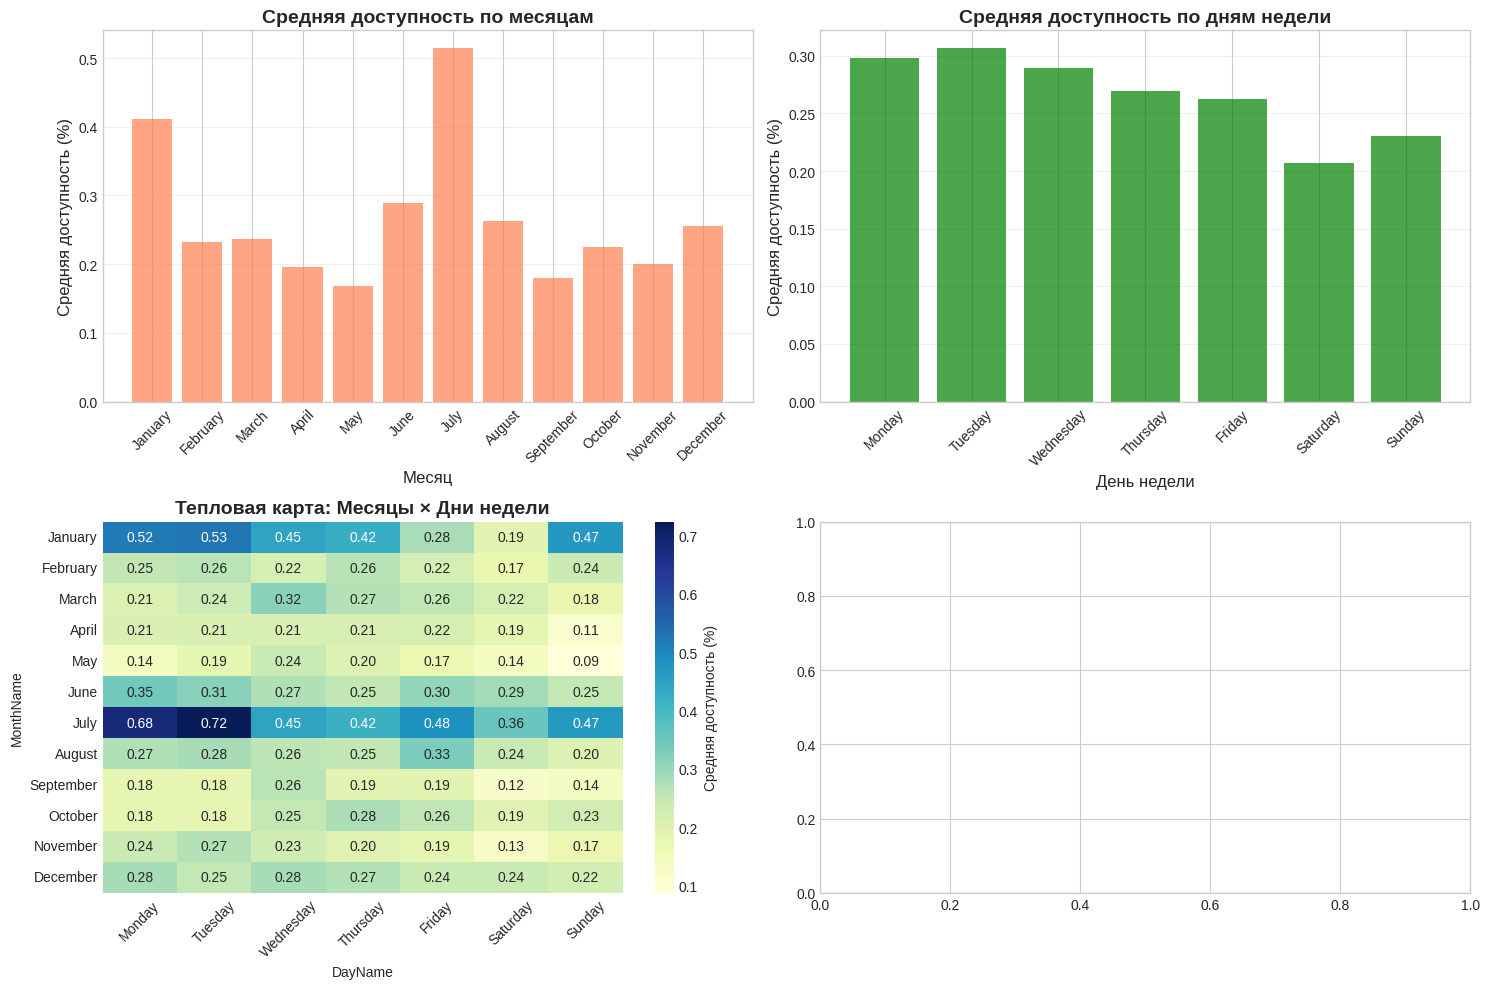

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# По месяцам (среднее)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_mean = df.groupby('MonthName')['Cell Avail Base Tech (%)'].mean().reindex(month_order)

axes[0, 0].bar(monthly_mean.index, monthly_mean.values, color='coral', alpha=0.7)
axes[0, 0].set_xlabel('Месяц', fontsize=12)
axes[0, 0].set_ylabel('Средняя доступность (%)', fontsize=12)
axes[0, 0].set_title('Средняя доступность по месяцам', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# По дням недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_mean = df.groupby('DayName')['Cell Avail Base Tech (%)'].mean().reindex(day_order)

axes[0, 1].bar(daily_mean.index, daily_mean.values, color='green', alpha=0.7)
axes[0, 1].set_xlabel('День недели', fontsize=12)
axes[0, 1].set_ylabel('Средняя доступность (%)', fontsize=12)
axes[0, 1].set_title('Средняя доступность по дням недели', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Heatmap: месяцы × дни недели
pivot_data = df.groupby(['MonthName', 'DayName'])['Cell Avail Base Tech (%)'].mean().unstack()
pivot_data = pivot_data.reindex(index=month_order, columns=day_order)

sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1, 0],
            cbar_kws={'label': 'Средняя доступность (%)'})
axes[1, 0].set_title('Тепловая карта: Месяцы × Дни недели', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('2_monthly_weekly.png', dpi=300, bbox_inches='tight')
plt.show()

- Pairplot для всех колонок доступности  
Сохранено в `3_scatter_pairs.png`
####

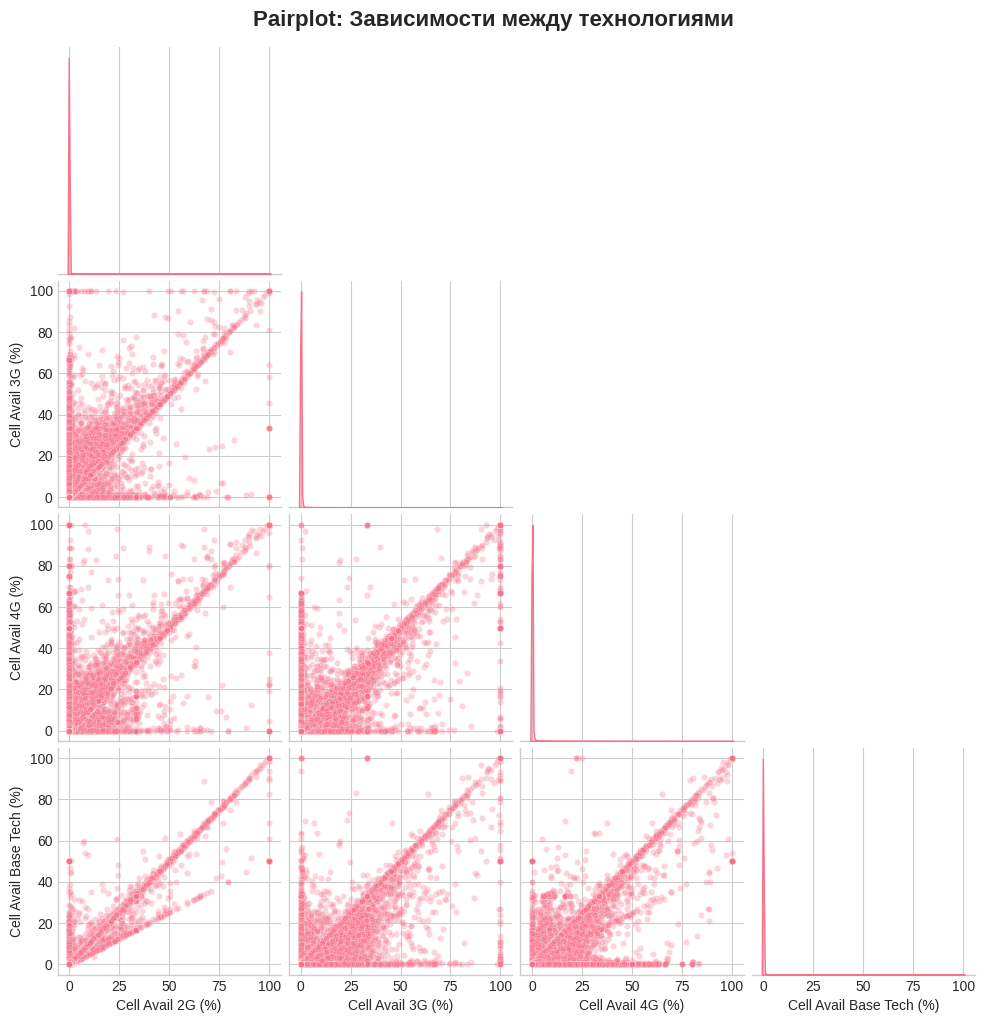

In [ ]:
# Pairplot для всех колонок доступности
pair_df = df[avail_cols].dropna()

g = sns.pairplot(pair_df, plot_kws={'alpha': 0.3, 's': 20},
                 diag_kind='kde', corner=True)
g.fig.suptitle('Pairplot: Зависимости между технологиями', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('3_scatter_pairs.png', dpi=300, bbox_inches='tight')
plt.show()

- Попарные scatter'ы технологий (2G vs 3G, 2G vs 4G, etc)  
Сохранено в `3_scatter_detailed.png`
####

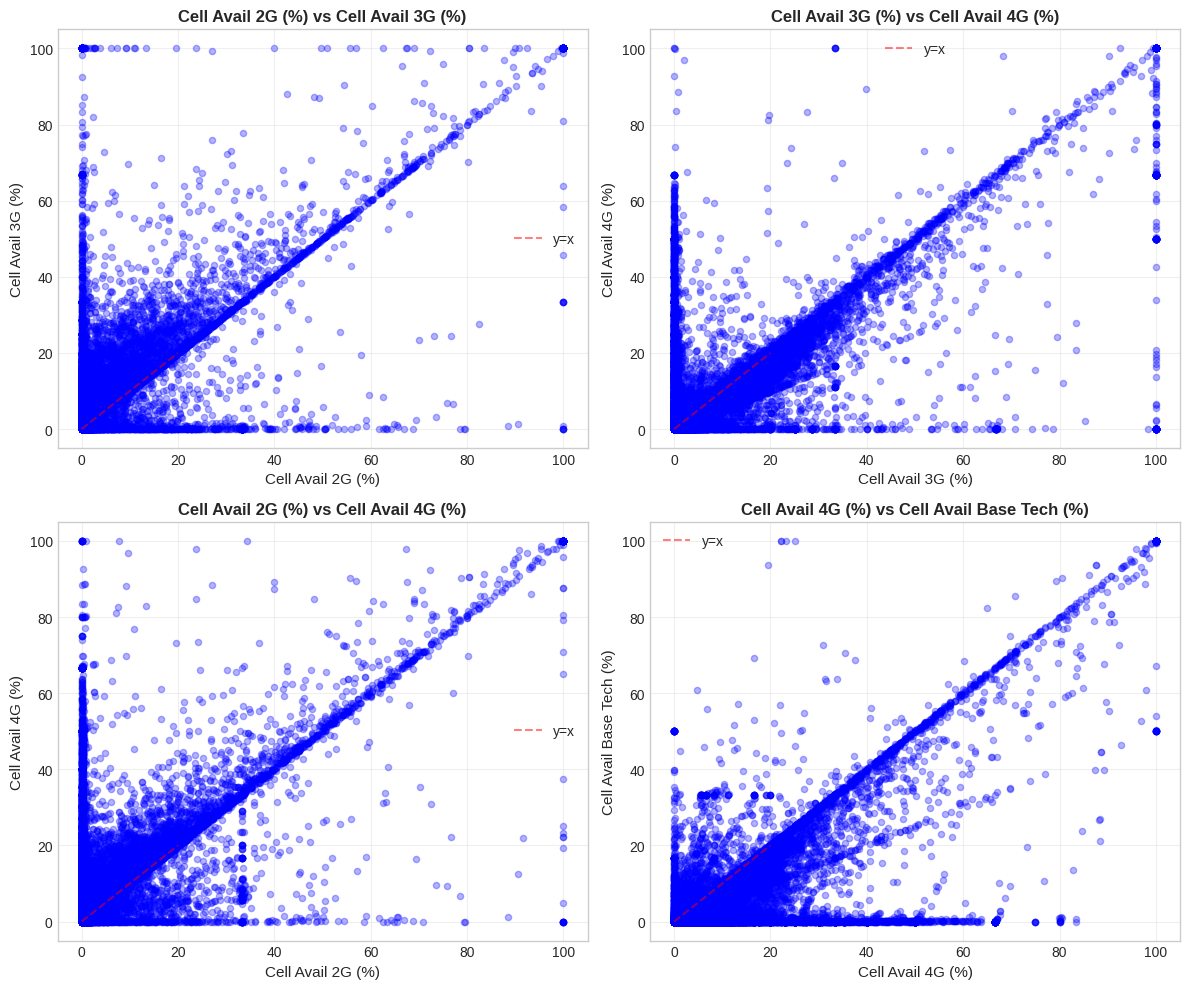

In [ ]:
# Отдельные scatter для 2G vs 3G, 3G vs 4G, etc.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

pairs = [('Cell Avail 2G (%)', 'Cell Avail 3G (%)'),
         ('Cell Avail 3G (%)', 'Cell Avail 4G (%)'),
         ('Cell Avail 2G (%)', 'Cell Avail 4G (%)'),
         ('Cell Avail 4G (%)', 'Cell Avail Base Tech (%)')]

for idx, (x_col, y_col) in enumerate(pairs):
    scatter_data = df[[x_col, y_col]].dropna()
    axes[idx].scatter(scatter_data[x_col], scatter_data[y_col],
                     alpha=0.3, s=20, color='blue')
    axes[idx].set_xlabel(x_col, fontsize=11)
    axes[idx].set_ylabel(y_col, fontsize=11)
    axes[idx].set_title(f'{x_col} vs {y_col}', fontsize=12, fontweight='bold')
    axes[idx].plot([0, 20], [0, 20], 'r--', alpha=0.5, label='y=x')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('3_scatter_detailed.png', dpi=300, bbox_inches='tight')
plt.show()


- Записи, где хотя бы одна <100%
- Матрица корреляций
- Heatmap корреляций
- Корреляции с Base Tech  
Сохранено в `4_correlation_matrix.png`
####

Записей где хотя бы одна < 100%: 86763 (11.74%)


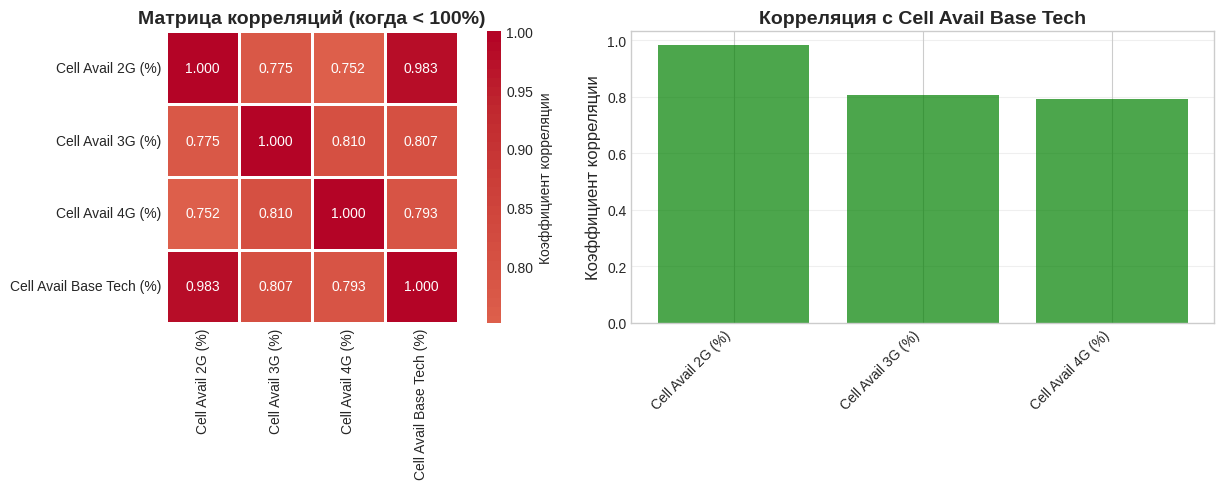


Матрица корреляций (когда хотя бы одна < 100%):
                          Cell Avail 2G (%)  Cell Avail 3G (%)  \
Cell Avail 2G (%)                     1.000              0.775   
Cell Avail 3G (%)                     0.775              1.000   
Cell Avail 4G (%)                     0.752              0.810   
Cell Avail Base Tech (%)              0.983              0.807   

                          Cell Avail 4G (%)  Cell Avail Base Tech (%)  
Cell Avail 2G (%)                     0.752                     0.983  
Cell Avail 3G (%)                     0.810                     0.807  
Cell Avail 4G (%)                     1.000                     0.793  
Cell Avail Base Tech (%)              0.793                     1.000  


In [ ]:
# Фильтр: хотя бы одна характеристика < 100%
mask_less_100 = (df[avail_cols] > 0).any(axis=1)
df_less_100 = df[mask_less_100][avail_cols]

print(f"Записей где хотя бы одна < 100%: {len(df_less_100)} ({len(df_less_100)/len(df)*100:.2f}%)")

# Матрица корреляций
corr_matrix = df_less_100.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap корреляций
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=axes[0],
            cbar_kws={'label': 'Коэффициент корреляции'})
axes[0].set_title('Матрица корреляций (когда < 100%)', fontsize=14, fontweight='bold')

# Корреляции с Base Tech
base_corr = corr_matrix['Cell Avail Base Tech (%)'].drop('Cell Avail Base Tech (%)')
colors = ['red' if x < 0 else 'green' for x in base_corr.values]
bars = axes[1].bar(range(len(base_corr)), base_corr.values, color=colors, alpha=0.7)
axes[1].set_xticks(range(len(base_corr)))
axes[1].set_xticklabels(base_corr.index, rotation=45, ha='right')
axes[1].set_ylabel('Коэффициент корреляции', fontsize=12)
axes[1].set_title('Корреляция с Cell Avail Base Tech', fontsize=14, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('4_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nМатрица корреляций (когда хотя бы одна < 100%):")
print(corr_matrix.round(3))



- Распределение доступности Base Tech
- Распределение значений <100%
- Распределение значений <98%
- Соотношение записей (100% vs <100%)  
Сохранено в `base_tech_distribution.png`
####

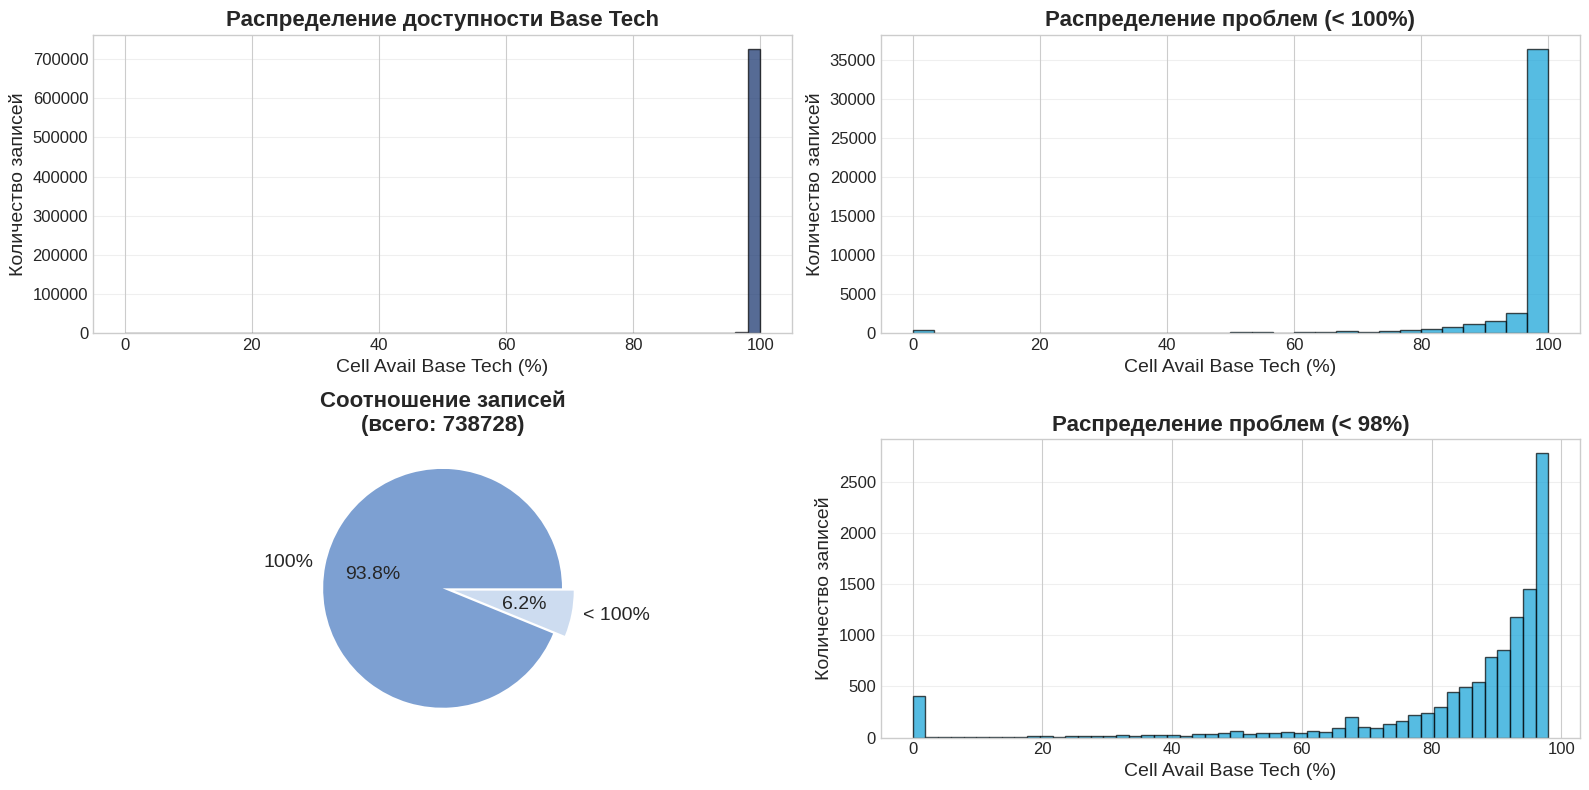

In [ ]:
df = df_cell_avail.copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# 1. Основная гистограмма
axes[0, 0].hist(df['Cell Avail Base Tech (%)'].dropna(),
                bins=50,
                edgecolor='black',
                alpha=0.7,
                color='#0F2D69')  # R15 G45 B105
axes[0, 0].set_xlabel('Cell Avail Base Tech (%)', fontsize=14)
axes[0, 0].set_ylabel('Количество записей', fontsize=14)
axes[0, 0].set_title('Распределение доступности Base Tech', fontsize=16, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(labelsize=12)

# 2. Гистограмма с фокусом на значения < 100%
df_problems = df[df['Cell Avail Base Tech (%)'] < 100]
if len(df_problems) > 0:
    axes[0, 1].hist(df_problems['Cell Avail Base Tech (%)'].dropna(),
                    bins=30,
                    edgecolor='black',
                    alpha=0.7,
                    color='#0FA0D7')  # R15 G160 B215
    axes[0, 1].set_xlabel('Cell Avail Base Tech (%)', fontsize=14)
    axes[0, 1].set_ylabel('Количество записей', fontsize=14)
    axes[0, 1].set_title('Распределение проблем (< 100%)', fontsize=16, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    axes[0, 1].tick_params(labelsize=12)
else:
    axes[0, 1].text(0.5, 0.5, 'Нет записей с доступностью < 100%',
                    ha='center', va='center', fontsize=14, transform=axes[0, 1].transAxes)
    axes[0, 1].set_xlim(0, 1)
    axes[0, 1].set_ylim(0, 1)
#3. Гистограмма с фокусом на значения < 98%
df_problems = df[df['Cell Avail Base Tech (%)'] < 98]
if len(df_problems) > 0:
    axes[1, 1].hist(df_problems['Cell Avail Base Tech (%)'].dropna(),
                    bins=50,
                    edgecolor='black',
                    alpha=0.7,
                    color='#0FA0D7')  # R15 G160 B215
    axes[1, 1].set_xlabel('Cell Avail Base Tech (%)', fontsize=14)
    axes[1, 1].set_ylabel('Количество записей', fontsize=14)
    axes[1, 1].set_title('Распределение проблем (< 98%)', fontsize=16, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    axes[1, 1].tick_params(labelsize=12)
else:
    axes[1, 1].text(0.5, 0.5, 'Нет записей с доступностью < 100%',
                    ha='center', va='center', fontsize=14, transform=axes[0, 1].transAxes)
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)

# 4. Pie chart: 100% vs < 100%
count_100 = (df['Cell Avail Base Tech (%)'] == 100).sum()
count_less_100 = (df['Cell Avail Base Tech (%)'] < 100).sum()
total = len(df)


axes[1, 0].pie([count_100, count_less_100],
               labels=['100%', '< 100%'],
               autopct='%1.1f%%',
               colors=['#7DA0D2', '#CDDCF0'],  # R125 G160 B210 и R205 G220 B240
               explode=[0, 0.1],
               textprops={'fontsize': 14})
axes[1, 0].set_title(f'Соотношение записей\n(всего: {total})', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('base_tech_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

- Распределение >=98%
####

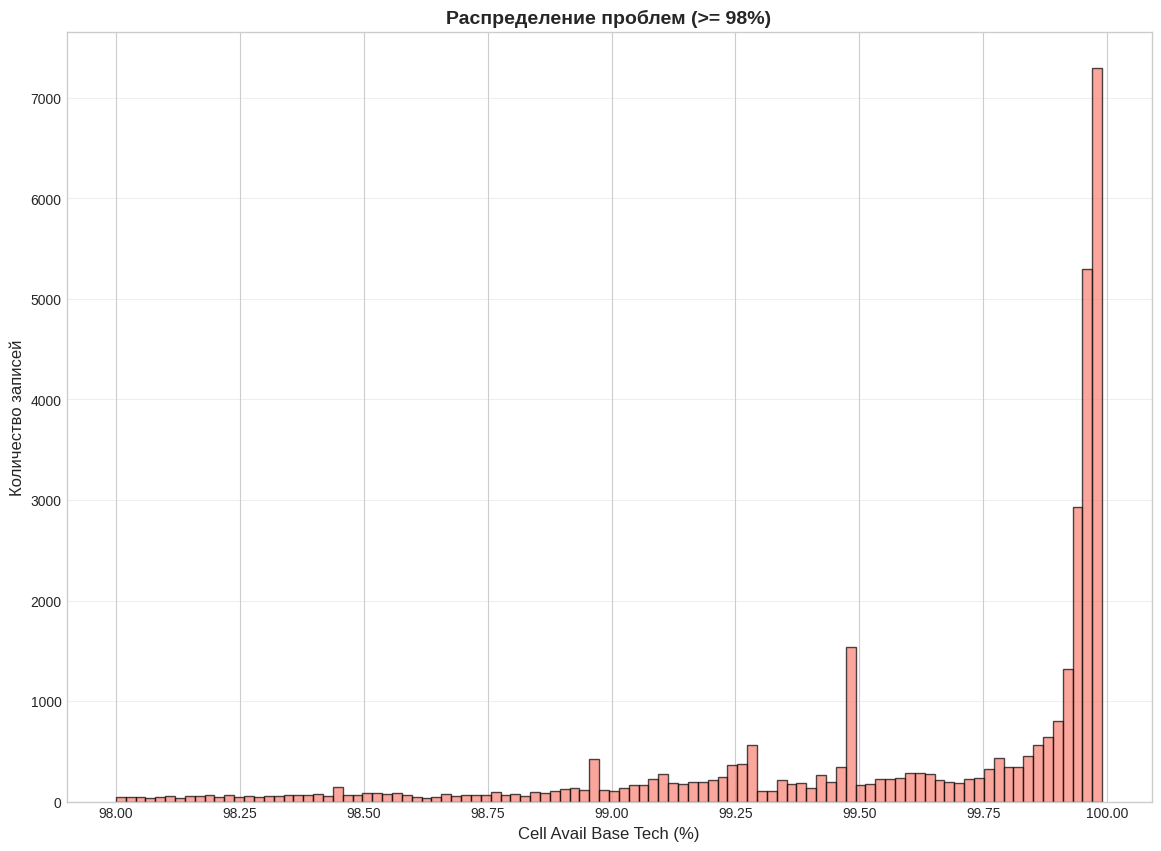

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
df_problems = df[(df['Cell Avail Base Tech (%)'] >= 98) & (df['Cell Avail Base Tech (%)'] < 100)]
if len(df_problems) > 0:
    axes.hist(df_problems['Cell Avail Base Tech (%)'].dropna(),
                    bins=100,
                    edgecolor='black',
                    alpha=0.7,
                    color='salmon')
    axes.set_xlabel('Cell Avail Base Tech (%)', fontsize=12)
    axes.set_ylabel('Количество записей', fontsize=12)
    axes.set_title('Распределение проблем (>= 98%)', fontsize=14, fontweight='bold')
    axes.grid(True, alpha=0.3, axis='y')
else:
    axes.text(0.5, 0.5, 'Нет записей с доступностью < 100%',
                    ha='center', va='center', fontsize=12, transform=axes[0, 1].transAxes)
    axes.set_xlim(0, 1)
    axes.set_ylim(0, 1)

- Гистограмма отраженных данных (100 - Avail)
- QQ-plot отраженных данных
####

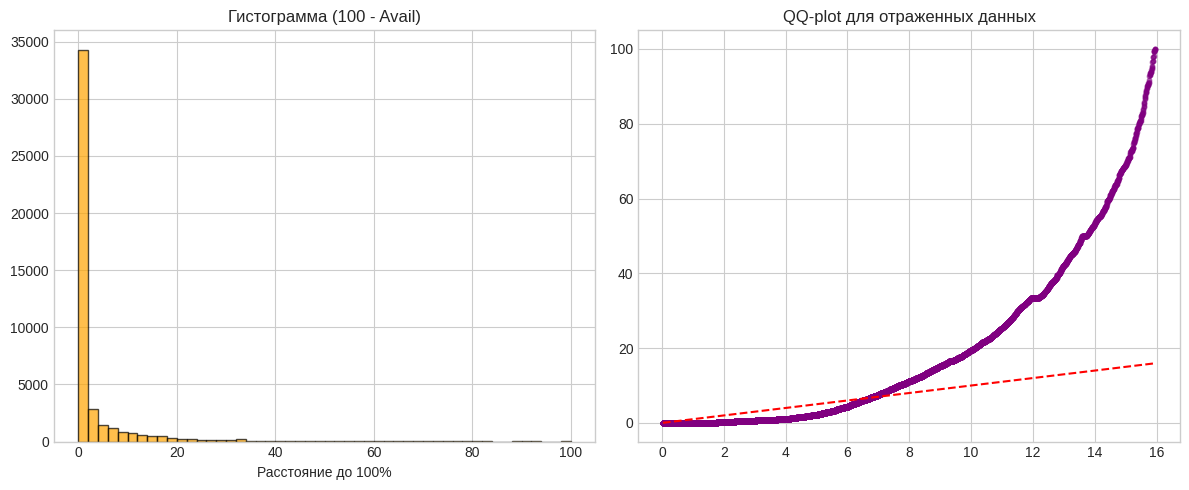

KS-тест для отраженных данных: p-value = 0.0000


In [ ]:
df_filtered = df[(df['Cell Avail Base Tech (%)'] < 100) & (df['Cell Avail Base Tech (%)'] > 0)]
data = df_filtered['Cell Avail Base Tech (%)'].dropna()

data_reflected = 100 - data

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(data_reflected, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_title('Гистограмма (100 - Avail)')
axes[0].set_xlabel('Расстояние до 100%')

rate_param = 1 / data_reflected.mean()
exp_quantiles = stats.expon.ppf(np.linspace(0.01, 0.99, len(data_reflected)), scale=1/rate_param)
data_sorted = np.sort(data_reflected)

axes[1].scatter(exp_quantiles, data_sorted, alpha=0.5, s=10, color='purple')
axes[1].plot([min(exp_quantiles), max(exp_quantiles)],
             [min(exp_quantiles), max(exp_quantiles)], 'r--')
axes[1].set_title('QQ-plot для отраженных данных')

plt.tight_layout()
plt.show()

ks_stat, ks_pvalue = stats.kstest(data_reflected, 'expon', args=(0, 1/rate_param))
print(f"KS-тест для отраженных данных: p-value = {ks_pvalue:.4f}")
if ks_pvalue > 0.05:
    print("Гипотеза об экспоненциальности (для 100-X) подтверждена")

- Топ 10 вышек по с худшей доступностью
####

Статистика по вышкам:
             Средняя доступность (%)  Медиана (%)  Стд. отклонение  \
Master Site                                                          
LE001865                      100.00        100.0             0.04   
SC001586                      100.00        100.0             0.06   
SP000966                      100.00        100.0             0.04   
LE002863                      100.00        100.0             0.00   
LE002920                      100.00        100.0             0.01   
...                              ...          ...              ...   
SP000730                       95.37        100.0            20.64   
SP002604                       94.80        100.0            21.94   
SP000936                       92.76        100.0            24.14   
SP001400                       92.08        100.0            26.44   
SP001381                       82.54        100.0            37.25   

             Кол-во дней  Мин (%)  Макс (%)  
Master Site          

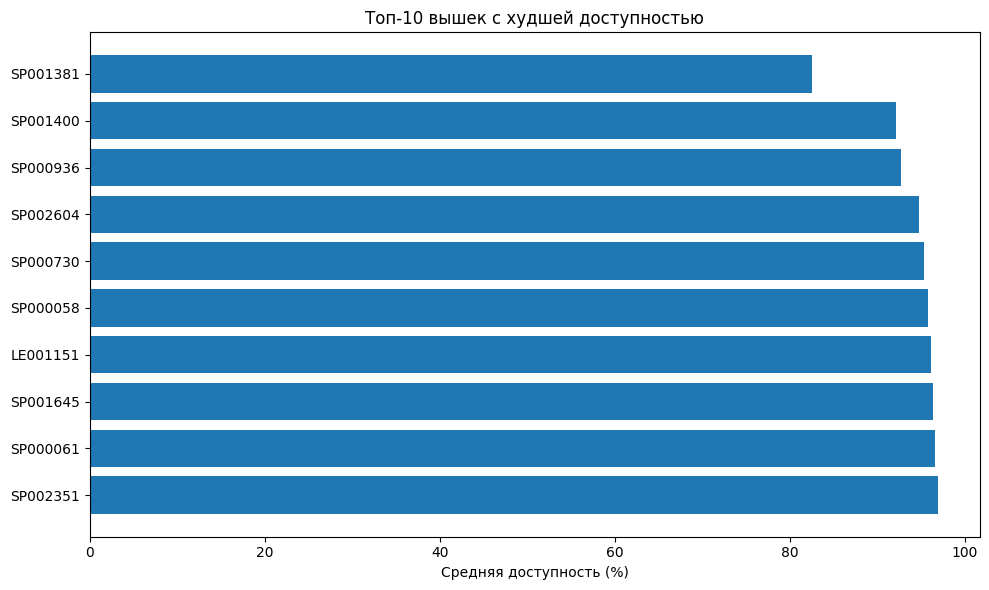

In [ ]:
avg_availability_by_tower = df.groupby('Master Site')['Cell Avail Base Tech (%)'].agg([
    'mean',      # среднее значение доступности
    'median',    # медиана
    'std',       # стандартное отклонение
    'count',     # количество записей (дней)
    'min',       # минимум
    'max'        # максимум
]).round(2)

avg_availability_by_tower.columns = ['Средняя доступность (%)',
                                      'Медиана (%)',
                                      'Стд. отклонение',
                                      'Кол-во дней',
                                      'Мин (%)',
                                      'Макс (%)']

print("Статистика по вышкам:")
print(avg_availability_by_tower.sort_values('Средняя доступность (%)', ascending=False))


if 'Date' in df.columns:
    stats_with_dates = df.groupby('Cell ID').agg({
        'Cell Avail Base Tech (%)': 'mean',
        'Date': 'nunique'  # количество уникальных дней
    }).round(2)

    stats_with_dates.columns = ['Средняя доступность (%)', 'Уникальных дней']
    print("\nСтатистика с уникальными днями:")
    print(stats_with_dates)

top_10_worst = avg_availability_by_tower.nsmallest(10, 'Средняя доступность (%)')

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_10_worst)), top_10_worst['Средняя доступность (%)'])
plt.yticks(range(len(top_10_worst)), top_10_worst.index)
plt.xlabel('Средняя доступность (%)')
plt.title('Топ-10 вышек с худшей доступностью')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

avg_availability_by_tower.to_csv('tower_availability_stats.csv')

Random Forest, Gradient Boosting
####

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
df = df_cell_avail.copy()
df['Target_Next_Day'] = df.groupby('Master Site')['Cell Avail Base Tech (%)'].shift(-1)
df_model = df.dropna(subset=['Target_Next_Day'])

bins = [0, 50, 70, 80, 90, 95, 98, 99, 100]
labels = ['0-50%', '50-70%', '70-80%', '80-90%', '90-95%', '95-98%', '98-99%', '99-100%']
df_model['availability_class'] = pd.cut(df_model['Target_Next_Day'], bins=bins, labels=labels, include_lowest=True)

numeric_features = ['Cell Avail 2G (%)', 'Cell Avail 3G (%)', 'Cell Avail 4G (%)', 'Cell Avail Base Tech (%)']
categorical_features = ['Master Site', 'Region', 'Subregion']

df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

feature_cols = numeric_features + [col for col in df_encoded.columns if any(cat in col for cat in categorical_features)]

X = df_encoded[feature_cols].fillna(0)
y = df_encoded['availability_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = RandomForestClassifier(n_estimators=200, class_weight='balanced', min_samples_split=2, min_samples_leaf=1, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("RandomForest Classification Report:")
print(classification_report(y_test, y_pred))

print("Recall by Class:")
recall_per_class = recall_score(y_test, y_pred, average=None, labels=labels)
for cls, rec in zip(labels, recall_per_class):
    print(f"{cls}: Recall = {rec:.4f}")

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("\nGradientBoosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

RandomForest Classification Report:
              precision    recall  f1-score   support

       0-50%       0.05      0.44      0.09       169
      50-70%       0.00      0.20      0.01       149
      70-80%       0.00      0.10      0.00       165
      80-90%       0.01      0.13      0.01       511
      90-95%       0.01      0.12      0.01       536
      95-98%       0.01      0.09      0.01       733
      98-99%       0.01      0.18      0.02       762
     99-100%       0.98      0.52      0.68    144352

    accuracy                           0.52    147377
   macro avg       0.13      0.22      0.10    147377
weighted avg       0.96      0.52      0.67    147377

Recall by Class:
0-50%: Recall = 0.4438
50-70%: Recall = 0.2013
70-80%: Recall = 0.0970
80-90%: Recall = 0.1311
90-95%: Recall = 0.1175
95-98%: Recall = 0.0914
98-99%: Recall = 0.1759
99-100%: Recall = 0.5237
